# Showcase — the Suez Canal blockage (Ever Given, March 2021)

On **23 March 2021** the 400 m container ship *Ever Given* ran aground and wedged across the Suez Canal, halting one of the world's busiest shipping lanes for six days until it was refloated on 29 March. This notebook pulls a Sentinel-2 time series around the blockage and renders it entirely through **pyramids' own plotting** — reading the scenes off disk with `DatasetCollection.read_multiple_files()` and drawing each one in **true colour** with `Dataset.plot(rgb_options=...)`.

## What this notebook does

1. **Fetch** a Sentinel-2 true-colour scene (`B4,B3,B2`) for six dates spanning the blockage, into one folder.
2. **Read** the folder as a collection with `DatasetCollection.read_multiple_files()`.
3. **Compare** before / during / after with `Dataset.plot(rgb_options=...)`.
4. **Show the full true-colour progression** across all six dates.
5. **Animate** the scenes as a real-colour GIF.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`; the download cells skip gracefully without credentials.

In [1]:
import os, shutil, tempfile, warnings
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own IO + plotting

warnings.filterwarnings("ignore")
logger.remove()
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

AOI = [32.570, 30.005, 32.592, 30.030]; COLL = "COPERNICUS/S2_SR_HARMONIZED"
DATES = ["2021-03-04", "2021-03-19", "2021-03-24", "2021-03-29", "2021-04-03", "2021-04-13"]
scene_dir = tempfile.mkdtemp()

def grab(bands, day, scale=10):
    """Download one Sentinel-2 median composite for `day`; return its GeoTIFF path (or None)."""
    el = EarthLens(data_source="gee", start=day, end=day, temporal_resolution="raw",
        variables={COLL: list(bands)}, lat_lim=[AOI[1], AOI[3]], lon_lim=[AOI[0], AOI[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer="median",
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - needs GEE credentials
        print("download skipped:", exc); return None
    return str(p[0]) if p else None

dates = []
for d in DATES:
    p = grab(["B4", "B3", "B2"], d)
    if p:
        shutil.copy(p, os.path.join(scene_dir, f"suez_{d.replace('-', '.')}.tif"))
        dates.append(d)
dc = DatasetCollection.read_multiple_files(scene_dir, date=False) if dates else None   # read the folder
print(f"{len(dates)} scenes:", dates)

6 scenes: ['2021-03-04', '2021-03-19', '2021-03-24', '2021-03-29', '2021-04-03', '2021-04-13']


## Before / during / after — `Dataset.plot()`

Each scene is rendered with pyramids' `Dataset.plot(rgb_options=...)`, which percentile-stretches the R/G/B bands and draws geographic axes. The 19 Mar canal flows normally; on 24 Mar the *Ever Given* is wedged across it; by 3 Apr traffic is moving again.

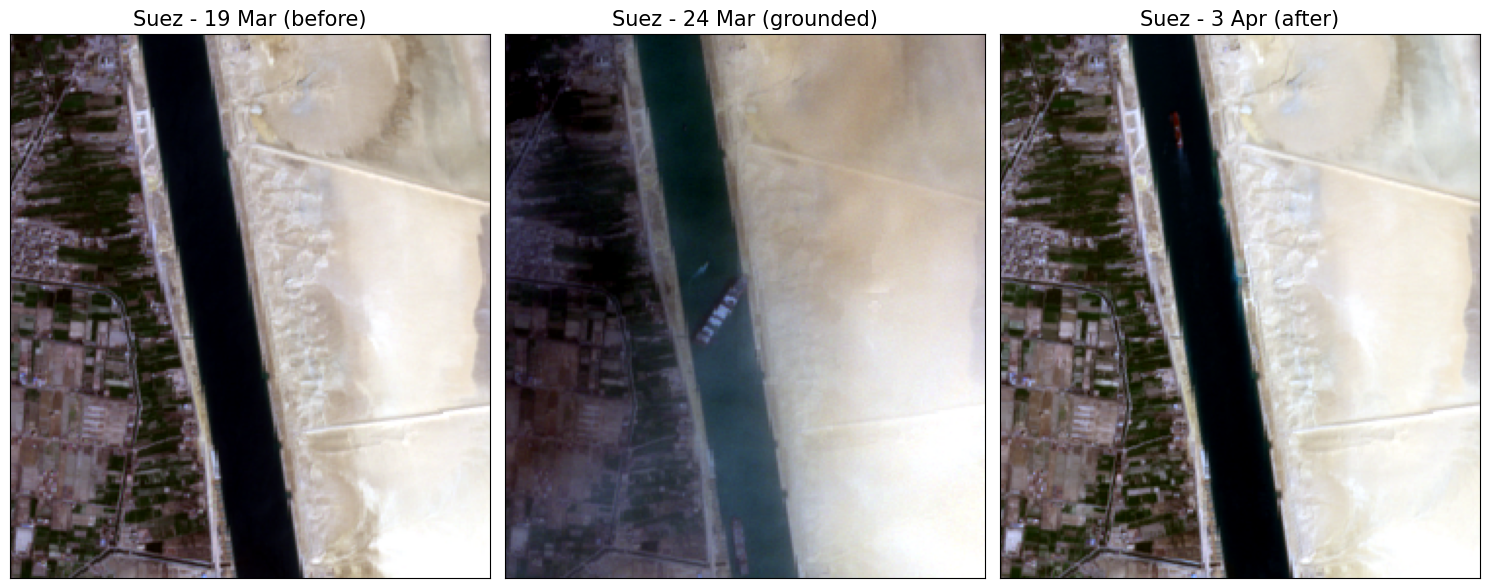

In [2]:
# True-colour stills straight from the collection (iloc -> Dataset.plot).
pick = {"19 Mar (before)": "2021-03-19", "24 Mar (grounded)": "2021-03-24", "3 Apr (after)": "2021-04-03"}
sel = [(t, dates.index(d)) for t, d in pick.items() if d in dates]
if sel:
    fig, axes = plt.subplots(1, len(sel), figsize=(5 * len(sel), 6))
    axes = np.atleast_1d(axes)
    for ax, (t, i) in zip(axes, sel):
        dc.iloc(i).plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2}, ax=ax, title=f"Suez - {t}")
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print("no scenes - set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")

## Full true-colour progression

All six dates rendered as real-colour composites with `Dataset.plot(rgb_options=...)`: the canal flows on 4–19 Mar, the *Ever Given* is wedged across it on 24 Mar, and traffic is moving again by 3–13 Apr.

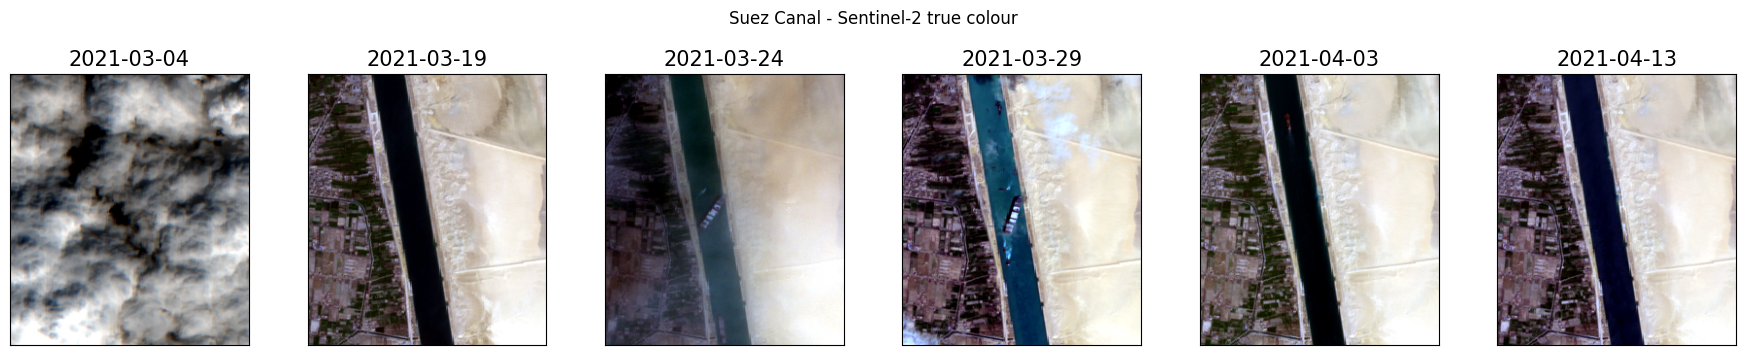

In [3]:
# Real-colour progression across all six dates - one Dataset.plot per scene.
if dc:
    n = dc.time_length
    fig, ax = plt.subplots(1, n, figsize=(3.0 * n, 3.4))
    for i, d in enumerate(dates):
        dc.iloc(i).plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2}, ax=ax[i], title=d)
        ax[i].set_xticks([]); ax[i].set_yticks([])
    fig.suptitle("Suez Canal - Sentinel-2 true colour", y=1.03)
    plt.tight_layout(); plt.show()
else:
    print("no scenes to show")

## Animated true colour

The six scenes as a real-colour animation — the *Ever Given* appears wedged across the canal, then clears. `DatasetCollection.plot()` animates a single band, so each RGB frame is prepared with cleopatra's `ArrayGlyph.prepare_array` and stepped into a GIF.

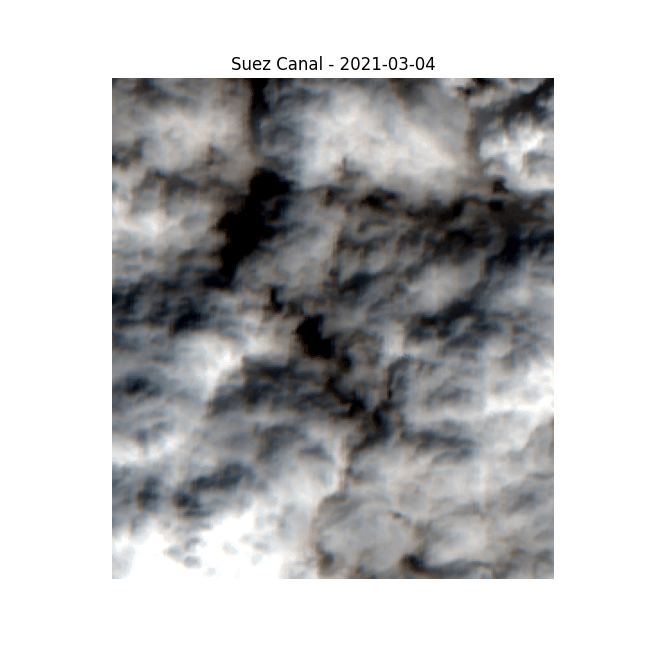

In [4]:
# DatasetCollection.plot animates ONE band, so for true colour we prepare each RGB
# frame with cleopatra's ArrayGlyph.prepare_array (the exact stretch Dataset.plot's
# rgb path uses) and step the frames with matplotlib into a GIF.
from IPython.display import Image, display
from cleopatra.array_glyph import ArrayGlyph
from matplotlib.animation import FuncAnimation, PillowWriter

if dc:
    helper = ArrayGlyph(np.zeros((1, 1)))   # bare glyph: only its prepare_array is used
    frames = [helper.prepare_array(np.asarray(dc.iloc(i).read_array(), dtype="float32")[:3],
                                   rgb=[0, 1, 2], percentile=2)
              for i in range(dc.time_length)]
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(frames[0]); ax.axis("off")
    def _step(i):
        im.set_data(frames[i]); ax.set_title(f"Suez Canal - {dates[i]}")
        return [im]
    anim = FuncAnimation(fig, _step, frames=len(frames), interval=800)
    gif = os.path.join(tempfile.mkdtemp(), "true_colour.gif")
    anim.save(gif, writer=PillowWriter(fps=1.2))
    plt.close(fig)
    display(Image(filename=gif))
else:
    print("no scenes to animate")

## Recap

The series is read from one folder with `DatasetCollection.read_multiple_files()`, every scene is drawn in true colour with `Dataset.plot(rgb_options=...)`, and the same scenes animate as a real-colour GIF (frames prepared by cleopatra's `prepare_array`).

## Try it yourself

- Change `DATES`/`AOI`, or add the NIR band for a false-colour view.
- See the [GEE backend reference](../../reference/gee/introduction.md).